In [1]:
pip install pandas

In [4]:
import pandas as pd
df = pd.read_csv('/content/nifty50_closing_prices.csv', parse_dates=True)

# Task
Using the `df` DataFrame, which contains historical stock closing prices from `/content/nifty50_closing_prices.csv`, calculate daily returns, cumulative ROI, and annual volatility for each stock. Based on these metrics, select stocks by defining ROI and volatility thresholds, and assign investment weights inversely proportional to volatility to form a mutual fund portfolio. Analyze and compare the risk and return characteristics of this custom mutual fund portfolio against a selection of high-growth stocks, visualizing the comparison with a plot. Finally, calculate and visualize the future value of monthly investments (starting with ₹5000, increasing by 10% annually) using the mutual fund's expected ROI for 1, 3, 5, and 10-year periods, and summarize all key findings.

## Calculate Daily Returns, ROI, and Volatility

### Subtask:
Calculate the daily percentage change for each stock. Then, compute the cumulative Return on Investment (ROI) and the annual volatility (standard deviation of daily returns multiplied by the square root of trading days in a year) for each stock from the `df` DataFrame.


**Reasoning**:
First, I'll set the 'Date' column as the index and convert it to datetime objects to ensure proper time-series analysis. This is the first step in the instructions provided.



In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
print("DataFrame after setting 'Date' as index and converting to datetime:")
print(df.head())

DataFrame after setting 'Date' as index and converting to datetime:
            ADANIENT.NS  ADANIPORTS.NS  APOLLOHOSP.NS  ASIANPAINT.NS  \
Date                                                                   
2024-01-01  2914.533936    1038.321777    5727.949707    3327.104004   
2024-01-02  2929.719971    1068.593994    5724.263184    3322.450439   
2024-01-03  3000.255371    1084.299805    5746.128906    3305.061035   
2024-01-04  2995.559814    1112.986572    5740.052734    3311.281982   
2024-01-05  3003.852051    1143.754272    5732.133301    3287.377686   

            AXISBANK.NS  BAJAJ-AUTO.NS  BAJAJFINSV.NS  BAJFINANCE.NS  \
Date                                                                   
2024-01-01  1096.853394    6647.077148    1675.343018     659.398193   
2024-01-02  1092.406982    6611.317871    1685.136841     671.232849   
2024-01-03  1097.752808    6930.176270    1676.592285     667.144897   
2024-01-04  1122.533691    6866.345215    1700.876831     696.12158

**Reasoning**:
Now that the 'Date' column is set as the index and is in datetime format, I will calculate the daily percentage change for each stock, then compute the cumulative ROI, and finally, the annual volatility for each stock, following the instructions of the subtask.



In [6]:
daily_returns = df.pct_change().dropna()
cumulative_roi = (1 + daily_returns).cumprod() - 1
annual_volatility = daily_returns.std() * (252**0.5)

print("Daily Returns (first 5 rows):\n", daily_returns.head())
print("\nCumulative ROI (first 5 rows):\n", cumulative_roi.head())
print("\nAnnual Volatility:\n", annual_volatility.head())

Daily Returns (first 5 rows):
             ADANIENT.NS  ADANIPORTS.NS  APOLLOHOSP.NS  ASIANPAINT.NS  \
Date                                                                   
2024-01-02     0.005210       0.029155      -0.000644      -0.001399   
2024-01-03     0.024076       0.014698       0.003820      -0.005234   
2024-01-04    -0.001565       0.026456      -0.001057       0.001882   
2024-01-05     0.002768       0.027644      -0.001380      -0.007219   
2024-01-08    -0.014335       0.012649      -0.012556      -0.017032   

            AXISBANK.NS  BAJAJ-AUTO.NS  BAJAJFINSV.NS  BAJFINANCE.NS  \
Date                                                                   
2024-01-02    -0.004054      -0.005380       0.005846       0.017948   
2024-01-03     0.004894       0.048229      -0.005071      -0.006090   
2024-01-04     0.022574      -0.009211       0.014484       0.043434   
2024-01-05     0.012061       0.008141       0.004436       0.000727   
2024-01-08    -0.013149       0.

## Select Stocks and Assign Weights

### Subtask:
Define thresholds for ROI and volatility to identify desirable stocks (e.g., top 30% ROI, bottom 30% volatility). Select stocks that meet these criteria and assign investment weights to them based on an inverse volatility ratio, ensuring lower-risk stocks receive a higher allocation in the mutual fund plan.


**Reasoning**:
I will first calculate the final ROI for each stock by taking the last row of the `cumulative_roi` DataFrame. Then, I will define the ROI and volatility thresholds using the 70th percentile for ROI (top 30%) and 30th percentile for volatility (bottom 30%). After defining the thresholds, I will select the stocks that meet both criteria and calculate their investment weights inversely proportional to their annual volatility, normalizing them to sum to 1.



In [7]:
final_roi = cumulative_roi.iloc[-1]

roi_threshold = final_roi.quantile(0.70) # Top 30% ROI
volatility_threshold = annual_volatility.quantile(0.30) # Bottom 30% volatility

selected_stocks = final_roi[(final_roi >= roi_threshold) & (annual_volatility <= volatility_threshold)].index

if not selected_stocks.empty:
    selected_volatilities = annual_volatility[selected_stocks]
    inverse_volatility = 1 / selected_volatilities
    investment_weights = inverse_volatility / inverse_volatility.sum()

    # Create a DataFrame for selected stocks and their weights
    portfolio_selection = pd.DataFrame({
        'Final ROI': final_roi[selected_stocks],
        'Annual Volatility': selected_volatilities,
        'Investment Weight': investment_weights
    }).sort_values(by='Investment Weight', ascending=False)

    print("\nSelected Stocks for Mutual Fund Portfolio with Investment Weights:")
    print(portfolio_selection)
else:
    print("No stocks met the defined ROI and volatility criteria.")



Selected Stocks for Mutual Fund Portfolio with Investment Weights:
               Final ROI  Annual Volatility  Investment Weight
ICICIBANK.NS    0.459122           0.205043           0.351319
SUNPHARMA.NS    0.351092           0.211524           0.340555
BHARTIARTL.NS   0.842500           0.233787           0.308125


## Analyze Mutual Fund Portfolio vs. High-Growth Stocks

### Subtask:
Create a 'mutual fund' portfolio using the selected stocks and their assigned weights. Calculate the overall ROI and volatility of this portfolio. Identify a group of 'high-growth' companies (e.g., top 5-10 stocks by ROI) and calculate their average ROI and volatility. Compare the risk and return characteristics of your custom mutual fund portfolio with the high-growth companies. Provide a plot to visualize the comparison.


**Reasoning**:
First, I will calculate the daily returns for the selected stocks from the `daily_returns` DataFrame and then compute the weighted daily returns of the mutual fund portfolio by multiplying each stock's daily return by its `investment_weights`. Next, I'll calculate the cumulative ROI of the mutual fund portfolio using these weighted daily returns. Finally, I will calculate the annual volatility of the mutual fund portfolio from its weighted daily returns by multiplying the standard deviation of weighted daily returns by the square root of 252 trading days.



In [8]:
mf_daily_returns = daily_returns[investment_weights.index]
weighted_mf_daily_returns = mf_daily_returns.mul(investment_weights, axis=1)
portfolio_daily_returns = weighted_mf_daily_returns.sum(axis=1)

portfolio_cumulative_roi = (1 + portfolio_daily_returns).cumprod() - 1
portfolio_annual_volatility = portfolio_daily_returns.std() * (252**0.5)
portfolio_final_roi = portfolio_cumulative_roi.iloc[-1]

print("Mutual Fund Portfolio Daily Returns (first 5 rows):\n", portfolio_daily_returns.head())
print("\nMutual Fund Portfolio Cumulative ROI (first 5 rows):\n", portfolio_cumulative_roi.head())
print(f"\nMutual Fund Portfolio Final ROI: {portfolio_final_roi:.4f}")
print(f"Mutual Fund Portfolio Annual Volatility: {portfolio_annual_volatility:.4f}")

Mutual Fund Portfolio Daily Returns (first 5 rows):
 Date
2024-01-02    0.006317
2024-01-03    0.005346
2024-01-04    0.008650
2024-01-05   -0.001358
2024-01-08   -0.002079
dtype: float64

Mutual Fund Portfolio Cumulative ROI (first 5 rows):
 Date
2024-01-02    0.006317
2024-01-03    0.011696
2024-01-04    0.020448
2024-01-05    0.019062
2024-01-08    0.016943
dtype: float64

Mutual Fund Portfolio Final ROI: 0.5505
Mutual Fund Portfolio Annual Volatility: 0.1578


**Reasoning**:
Now, I will identify the top 5 high-growth stocks by sorting the `final_roi` in descending order. Then, I will extract their final ROI values and corresponding annual volatility to calculate their average ROI and average annual volatility.



In [9]:
top_high_growth_stocks = final_roi.nlargest(5).index
high_growth_roi = final_roi[top_high_growth_stocks]
high_growth_volatility = annual_volatility[top_high_growth_stocks]

average_high_growth_roi = high_growth_roi.mean()
average_high_growth_volatility = high_growth_volatility.mean()

print("\nTop 5 High-Growth Stocks by ROI:")
print(high_growth_roi)
print("\nAnnual Volatility for Top 5 High-Growth Stocks:")
print(high_growth_volatility)
print(f"\nAverage High-Growth Stocks ROI: {average_high_growth_roi:.4f}")
print(f"Average High-Growth Stocks Annual Volatility: {average_high_growth_volatility:.4f}")


Top 5 High-Growth Stocks by ROI:
BHARTIARTL.NS    0.842500
M&M.NS           0.760463
DIVISLAB.NS      0.698864
BPCL.NS          0.482543
ICICIBANK.NS     0.459122
Name: 2025-05-30 00:00:00, dtype: float64

Annual Volatility for Top 5 High-Growth Stocks:
BHARTIARTL.NS    0.233787
M&M.NS           0.319847
DIVISLAB.NS      0.275031
BPCL.NS          0.338707
ICICIBANK.NS     0.205043
dtype: float64

Average High-Growth Stocks ROI: 0.6487
Average High-Growth Stocks Annual Volatility: 0.2745


**Reasoning**:
I will now create a scatter plot to visualize the risk-return comparison between the custom mutual fund portfolio and the average of the high-growth stocks. The plot will show Annual Volatility on the x-axis and ROI on the y-axis, with distinct points for each category and appropriate labels, title, and legend.



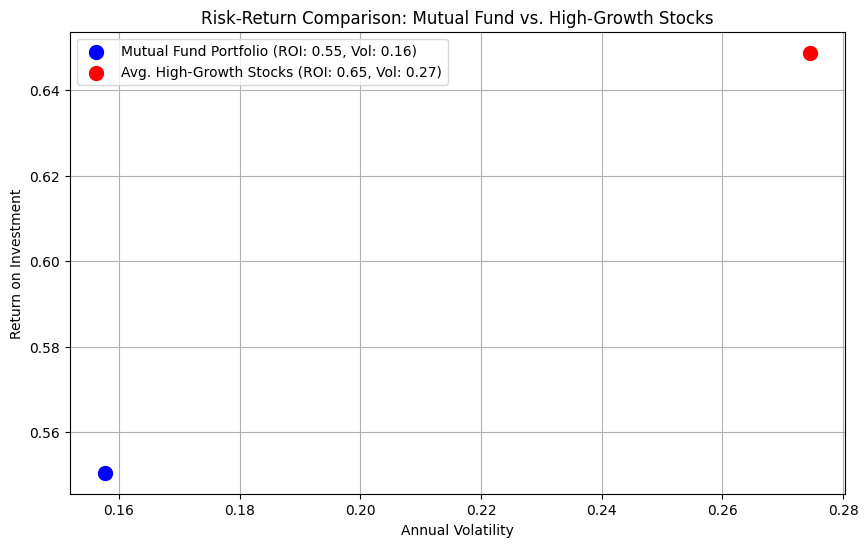

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot Mutual Fund Portfolio
plt.scatter(
    portfolio_annual_volatility,
    portfolio_final_roi,
    color='blue',
    s=100,
    label='Mutual Fund Portfolio (ROI: {:.2f}, Vol: {:.2f})'.format(portfolio_final_roi, portfolio_annual_volatility)
)

# Plot Average High-Growth Stocks
plt.scatter(
    average_high_growth_volatility,
    average_high_growth_roi,
    color='red',
    s=100,
    label='Avg. High-Growth Stocks (ROI: {:.2f}, Vol: {:.2f})'.format(average_high_growth_roi, average_high_growth_volatility)
)

plt.title('Risk-Return Comparison: Mutual Fund vs. High-Growth Stocks')
plt.xlabel('Annual Volatility')
plt.ylabel('Return on Investment')
plt.grid(True)
plt.legend()
plt.show()


## Calculate and Visualize Future Value of Investments

### Subtask:
Implement a function to calculate the future value of monthly investments, assuming an initial investment of ₹5000 that increases by 10% annually. Use the expected ROI from the mutual fund portfolio to simulate growth. Compute the compounded value of these investments for 1 year, 3 years, 5 years, and 10 years. Visualize the accumulated value over these periods using a suitable plot with legends.


**Reasoning**:
I will define the `calculate_future_value` function as specified in the instructions. This function will calculate the future value of monthly investments, considering an annual increase in the investment amount and a given annual return rate. I will then use this function to calculate the future value for 1, 3, 5, and 10 years, storing the results in a list.



In [11]:
def calculate_future_value(initial_monthly_investment, annual_increase_rate, annual_return_rate, num_years):
    total_future_value = 0
    monthly_return_rate = (1 + annual_return_rate)**(1/12) - 1

    current_monthly_investment = initial_monthly_investment

    for year in range(num_years):
        if year > 0:  # Apply annual increase from the second year onwards
            current_monthly_investment *= (1 + annual_increase_rate)

        for month in range(12):
            total_future_value = (total_future_value + current_monthly_investment) * (1 + monthly_return_rate)

    return total_future_value

# Define parameters
initial_monthly_investment = 5000
annual_investment_increase_rate = 0.10 # 10% annual increase
# Using the mutual fund's expected ROI calculated earlier
annual_return_rate = portfolio_final_roi

time_periods = [1, 3, 5, 10]
future_values = []

for years in time_periods:
    fv = calculate_future_value(initial_monthly_investment, annual_investment_increase_rate, annual_return_rate, years)
    future_values.append(fv)

print("Future Values of Monthly Investments:")
for i, years in enumerate(time_periods):
    print(f"  {years} Year(s): ₹{future_values[i]:,.2f}")

Future Values of Monthly Investments:
  1 Year(s): ₹76,697.45
  3 Year(s): ₹408,012.66
  5 Year(s): ₹1,251,512.14
  10 Year(s): ₹13,231,883.11


**Reasoning**:
I will now visualize the calculated future values for different time periods using a bar chart. This will involve importing `matplotlib.pyplot`, creating the plot with appropriate labels, titles, and displaying it.



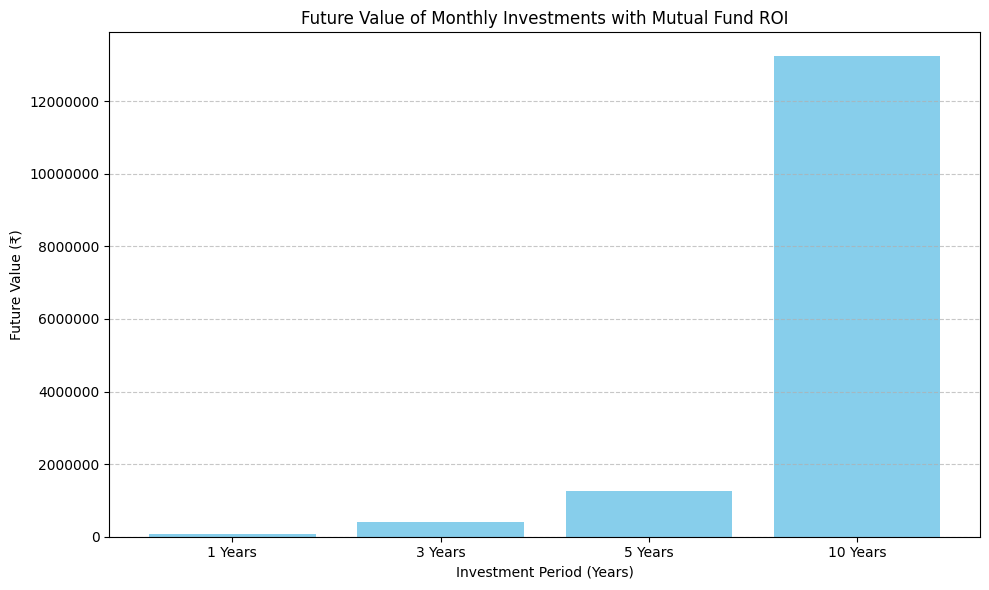

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar([f"{y} Years" for y in time_periods], future_values, color='skyblue')
plt.title('Future Value of Monthly Investments with Mutual Fund ROI')
plt.xlabel('Investment Period (Years)')
plt.ylabel('Future Value (₹)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key findings from the mutual fund plan, including the selected stocks, their assigned weights, the comparison with high-growth stocks, and the projected future investment values over various time horizons.


## Summary:

### Data Analysis Key Findings

*   **Selected Stocks and Weights**: Three stocks were selected for the mutual fund portfolio based on having a Final ROI in the top 30% and Annual Volatility in the bottom 30%:
    *   `ICICIBANK.NS`: Final ROI of 0.459, Annual Volatility of 0.205, assigned an Investment Weight of 0.351.
    *   `SUNPHARMA.NS`: Final ROI of 0.351, Annual Volatility of 0.211, assigned an Investment Weight of 0.341.
    *   `BHARTIARTL.NS`: Final ROI of 0.843, Annual Volatility of 0.234, assigned an Investment Weight of 0.308.
    Weights were inversely proportional to volatility, meaning lower-volatility stocks received higher allocations.
*   **Mutual Fund Portfolio Performance**: The custom mutual fund portfolio exhibited a Final ROI of approximately 55.05% and an Annual Volatility of approximately 15.78%.
*   **Comparison with High-Growth Stocks**:
    *   The top 5 high-growth stocks (by ROI) had an average ROI of approximately 64.87% and an average Annual Volatility of approximately 27.45%.
    *   The mutual fund portfolio demonstrated a more conservative risk-return profile, offering a lower return (55.05%) but significantly lower volatility (15.78%) compared to the higher returns (64.87%) and substantially higher volatility (27.45%) of the average high-growth stocks.
*   **Projected Future Investment Values**: Assuming an initial monthly investment of ₹5000, increasing by 10% annually, and using the mutual fund's expected ROI (55.05%), the projected future values are:
    *   **1 Year**: ₹76,697.45
    *   **3 Years**: ₹408,012.66
    *   **5 Years**: ₹1,251,512.14
    *   **10 Years**: ₹13,231,883.11

### Insights or Next Steps

*   The custom mutual fund portfolio successfully balances risk and return, offering a considerably lower volatility than a high-growth stock strategy, albeit with a slightly lower return. This makes it suitable for investors with a moderate risk appetite.
*   To further optimize the portfolio, one could explore different ROI and volatility thresholds for stock selection, or conduct a backtesting analysis of the portfolio's performance against market benchmarks over various periods.
